# Introduction to Neural Network Classification Part 2

In my part 1 , I talked a lot about binary classification. In this article, I'm going to talk about multi-class classification.

- [LinkedIn](https://www.linkedin.com/in/pro-programmer/),
- [YouTube](http://www.youtube.com/@itvaya),
- [Gmail](talukderrishat2@gmail.com),
- [discord](https://discord.gg/ZB495XggcF),

**You can find all my articles and code on**

- [Deep Learning With Tensorflow](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow),

**If you are new to Machine learning, I also have a github for begennier machine learning.**

- [Machine Learning Zero to Hero](https://github.com/RishatTalukder/Machine-Learning-Zero-to-Hero)

**Pre-requisites**

- Python.
- Numpy.
- Pandas.
- Matplotlib/Seaborn.
- Basics of data analysis and preprocessing.
- Basics ML terminologies.
- Basics Tensorflow and keras terminologies.
- Basics of Neural Network.
- [Read the previous article](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow/blob/main/pdfs/4_Neural_Network_Classification.pdf).

**Installations**

We need to install Tensorflow. To do so, we will use the following command:

```bash
    pip install tensorflow
```

or If you have conda installed,
    
```bash
    conda install tensorflow
```

Now, let's import the necessary libraries and check the version of TensorFlow we are using.

# Get the Data

I'll use the mnist dataset for this article.

If you've installed `tensorflow` properly then you can use the following command to download the dataset.

Altough I'll be talking about the data a lot but if you want you can see details about the dataset [here](https://www.tensorflow.org/datasets/catalog/mnist).



In [4]:
import tensorflow as tf
from keras.datasets import mnist

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


We can directly load the dataset and the dataset is already split for us.

This dataset contains the images of the digits from 0 to 9. Each picture is a `28x28` image. 

Let's see the size of the dataset.

In [9]:
len(x_train)

60000

In [10]:
len(x_test)

10000

The training set has 60000 images and set testing set has 10000 images. 

Let's see how many categories we have in the training set.

In [12]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

As you can see the target variable has values from 0 to 10, That means 10 classes.

So, Our objective is very simple, we want to classify the images into 10 classes.

But how does oue data look like?

In [14]:

print(f'the shape of each image is {x_train[0].shape}')

x_train[0]

the shape of each image is (28, 28)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

It's a 28 by 28 2D matrix.

UMMMMMM... 

What does the values represent?

We might be able to figure out something if we see the range of values.

In [20]:
print(f'max value of each image is {np.max(x_train[0])}')
print(f'min value of each image is {np.min(x_train[0])}')

max value of each image is 255
min value of each image is 0


Owh, 0 to 255. I want you to figure out what this means.

I hope you did try to figure this out on your own.

The values represent the color of the pixels in the image. We can plot this using the following code:

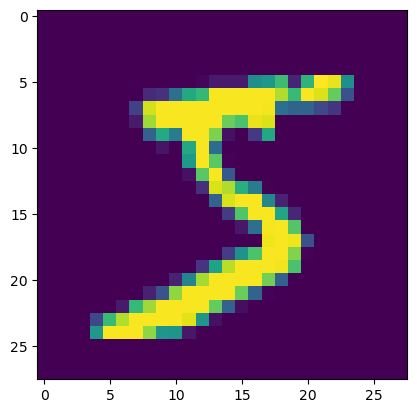

In [ ]:
import matplotlib.pyplot as plt

image = x_train[0]

plt.imshow(image)


Would you look at that!

it's an image of `5`.

Let's see if I'm right.

In [22]:
y_train[0]

np.uint8(5)

let's try another one.

This is the image of 2


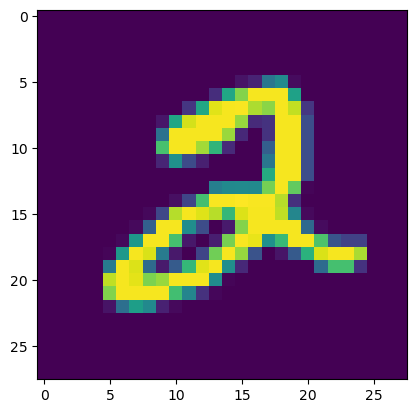

In [23]:
image = x_train[5]

plt.imshow(image)

print(f'This is the image of {y_train[5]}')

Now here's the color might look a bit weird, But the main color is in black and white.

I'll write a simple script to show different images and their corresponding labels with correct color.

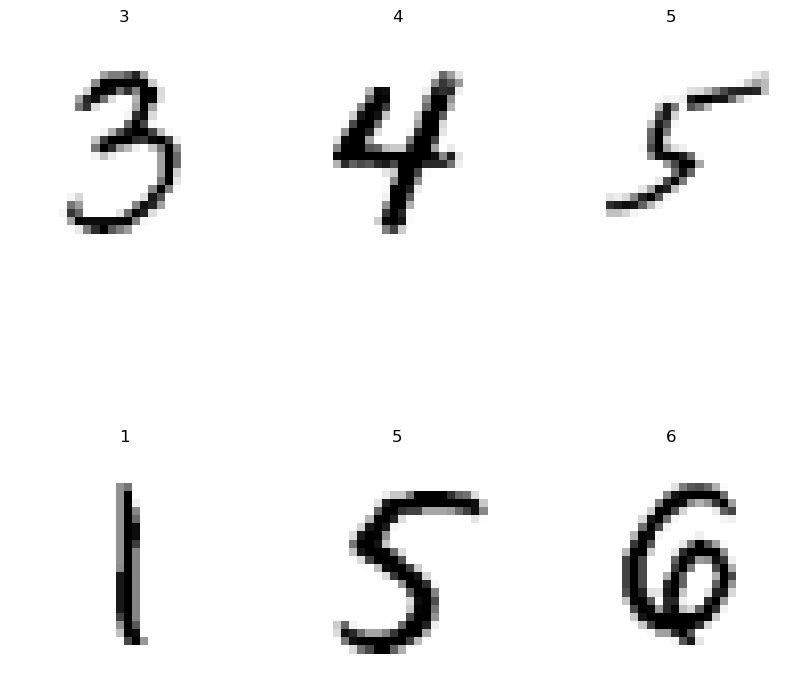

In [38]:
import random 

plt.figure(figsize=(10,10))

for i in range(6):
    ax = plt.subplot(2,3,i+1)
    rand_index = random.choice(range(len(x_train)))
    plt.imshow(x_train[rand_index], cmap=plt.cm.binary)
    plt.title(y_train[rand_index])
    plt.axis('off')
    
plt.show()

Not bad! not bad!

We have a lot of hand written digits and it seems like they are all correctly classified.

And now for the fun part, let's try to classify the digits using a neural network.

# Building a Multi-Class Classification Model

Here's what we did for binary classification:

- Input Layer.
- Hidden Layer.
- Output Layer of only one neuron.

In multi-class classification, we predict multiple classes. So, one neuron in the output layer will not be enough. We need to have multiple neurons in the output layer.

Rule of thumb is **one neuron per class**.

In the output layer, we have to set one neuron per class. 

There's another thing we need to change that is the activation function of the output layer.

For binary classification, we use the sigmoid function. But for multi-class classification, we have to use `softmax` function.

## What is the `softmax` function?

While the sigmoid function squashes a single number into a probability between 0 and 1, it only works when choosing between two options (Yes/No). When we have multiple neurons in our output layer, each neuron outputs its own raw score (called a logit). These raw numbers can be anything—negative, positive, small, or massive.

The softmax function takes all of these raw scores together and transforms them into a probability distribution. It does this by enforcing two strict rules:

   1. Every individual class gets a probability between 0 and 1 (0% to 100%).
   2. All the probabilities must add up to exactly 1 (100%).

The math is pretty simple:

$$
\text{Softmax}(x_1, x_2, x_3, \dots, x_n) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}} 
$$

## How Softmax Works: An Example
Imagine we are building a model to classify images of pets into three classes: Dog, Cat, or Bird. Because we have 3 classes, our output layer has 3 neurons.
When we feed a picture of a fuzzy animal into the model, the final layer outputs these raw scores (logits):

* Dog neuron: 2.0
* Cat neuron: 1.0
* Bird neuron: -1.0

Looking at these raw numbers, the model clearly thinks it's a dog, but these aren't probabilities. To convert them, Softmax performs a 2-step calculation:

### Step 1: Turn everything positive using Exponents ($e^x$)
To get rid of negative numbers (like the Bird's -1.0) and widen the gap between high and low scores, Softmax raises Euler's number ($e \approx 2.718$) to the power of each raw score:

* Dog ($e^{2.0}$): $\approx 7.39$
* Cat ($e^{1.0}$): $\approx 2.72$
* Bird ($e^{-1.0}$): $\approx 0.37$

Total Sum of Exponents: $7.39 + 2.72 + 0.37 = \mathbf{10.48}$

**Why Exponents of $e$? Why not $2$ or $3$?**

Why choose this random, messy decimal ($e \approx 2.718$) instead of clean, friendly integers like $2$ or $3$?

The short answer is: You could technically use 2 or 3 to turn the numbers positive, but we use Euler's number because of its unique properties in calculus.

In neural networks, everything relies on calculating derivatives (gradients) during backpropagation so the model can learn. Euler’s number makes the calculus incredibly clean and efficient.

**The Magic of Calculus (The Biggest Reason)**

In calculus, Euler’s number $e$ has a legendary superpower: it is the only function whose derivative is exactly itself.

$$
\frac{d}{dx}(e^x) = e^x 
$$ 

If you were to use $2^x$ or $3^x$, their derivatives are messy and require multiplying by an extra scaling factor every single time:

* Derivative of $2^x = 2^x \cdot \ln(2)$
* Derivative of $3^x = 3^x \cdot \ln(3)$

Because a neural network has to calculate derivatives for millions of parameters across thousands of training steps, using $2$ or $3$ would force the computer to constantly multiply by these extra natural log fractions ($\ln(2)$ or $\ln(3)$). Using $e$ strips away all that mathematical clutter, making the code run significantly faster and cleaner.

**The Perfect Cancel-Out with Cross-Entropy**

When you train a multi-class model, you pair the softmax activation function with a loss function called `Categorical Cross-Entropy`.

Cross-Entropy relies heavily on the natural logarithm ($\ln$), which is a logarithm with a base of... you guessed it, $e$.

Because the logarithm in the loss function and the exponent in the Softmax function both use the base $e$, they perfectly cancel each other out when calculating the gradient:

$$
\ln(e^x) = x
$$ 

This beautiful mathematical harmony completely eliminates the risk of complex fractions and prevents gradients from slowing down or glitching out during training. It ensures that the "kick" the optimizer gives the weights is perfectly proportional to how wrong the model's guess was.

So, the simple answer to why use $e^x$? By using $e$, the math beautifully simplifies during training, allowing the computer to calculate weight updates incredibly fast without getting bogged down by messy fractions.

### Step 2: Normalize to get the Percentage

Next, it divides each individual score by the total sum ($10.48$). This yields the final, clean probabilities:

* Dog Probability: $7.39 / 10.48 = \mathbf{0.705}$ (70.5%)
* Cat Probability: $2.72 / 10.48 = \mathbf{0.260}$ (26.0%)
* Bird Probability: $0.37 / 10.48 = \mathbf{0.035}$ (3.5%)


### The Final Prediction

Just like BinaryAccuracy used a 0.5 threshold for a single neuron, a multi-class model simply looks for the highest probability in the group (a function called argmax). In this case, the model confidently outputs Dog with 70.5% certainty.

